<a href="https://colab.research.google.com/github/kiruthigapandi02-max/2026-FDP-DSU/blob/main/Data_Analytics_on_Titanic_Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files
uploaded = files.upload()

Saving Titanic-Dataset (1).csv to Titanic-Dataset (1).csv


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')
import os
os.listdir()

['.config', 'Titanic-Dataset (1).csv', 'sample_data']

In [8]:

df = pd.read_csv('Titanic-Dataset (1).csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          891 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Embarked     891 non-null    object 
dtypes: float64(2), int64(5), object(4)
memory usage: 76.7+ KB


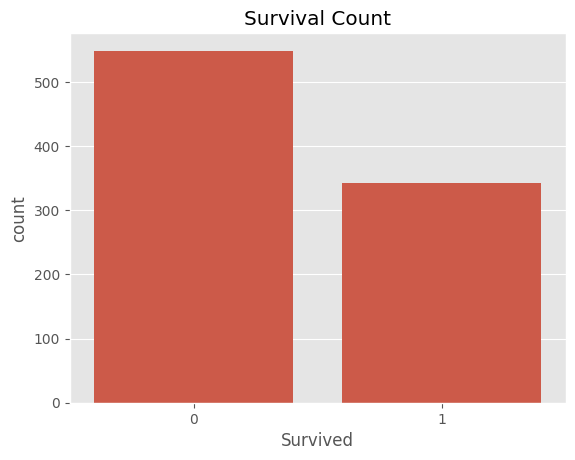

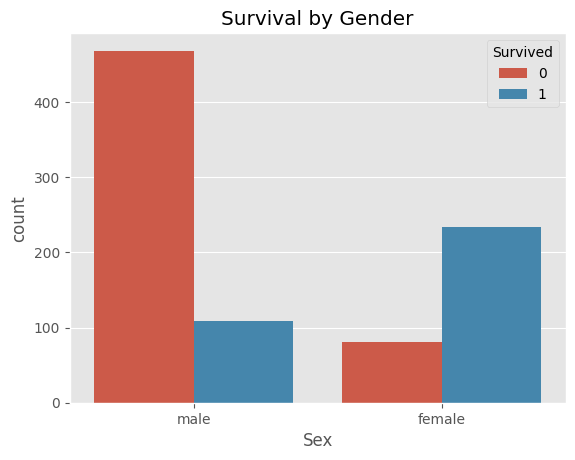

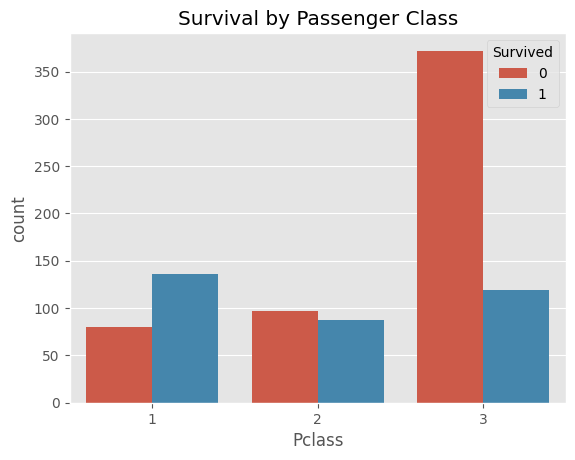

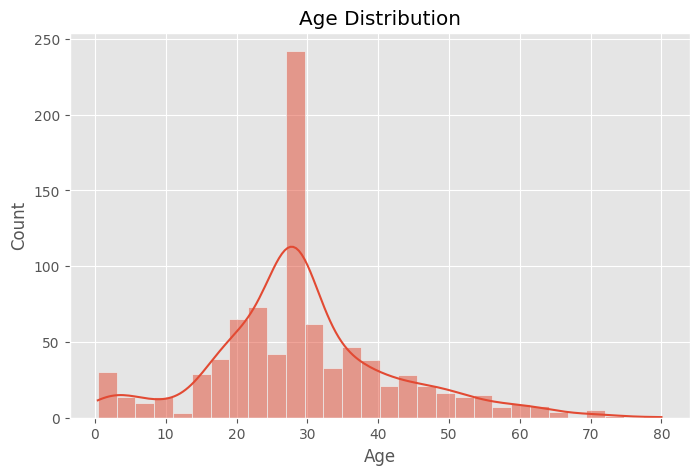

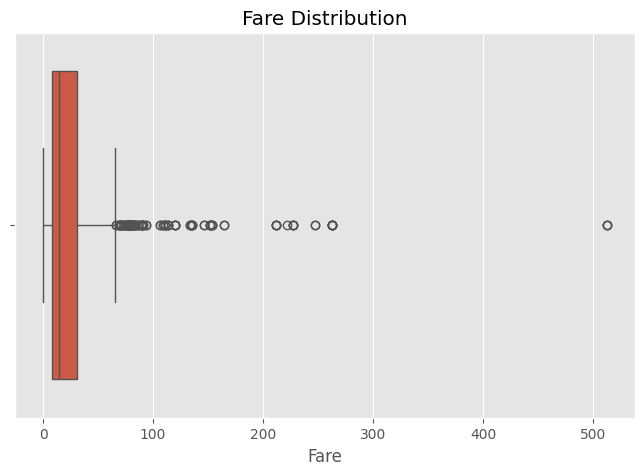

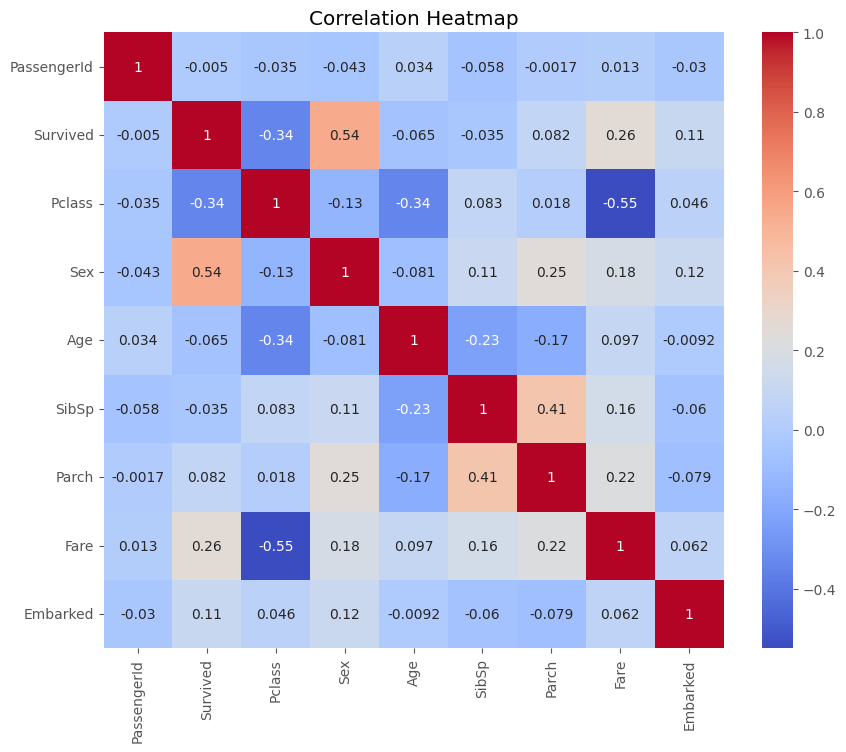

Total Passengers: 891
Survived: 342
Not Survived: 549

Survival Rate by Gender
Sex
female    74.203822
male      18.890815
Name: Survived, dtype: float64

Survival Rate by Passenger Class
Pclass
1    62.962963
2    47.282609
3    24.236253
Name: Survived, dtype: float64


In [19]:
df.info()
df.describe()
df.isnull().sum()

df['Age'] = df['Age'].fillna(df['Age'].median())
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])
#df.drop('Cabin', axis=1, inplace=True)
df.columns
#df.drop('Cabin', axis=1, inplace=True)
df.drop('Cabin', axis=1, inplace=True, errors='ignore')

df.isnull().sum()
#start Data Analytics (EDA)
#Survival Count
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='Survived', data=df)
plt.title('Survival Count')
plt.show()
#Survival by Gender
sns.countplot(x='Sex', hue='Survived', data=df)
plt.title('Survival by Gender')
plt.show()

#Survival by Passenger Class

sns.countplot(x='Pclass', hue='Survived', data=df)
plt.title('Survival by Passenger Class')
plt.show()

#Age Distribution

plt.figure(figsize=(8,5))
sns.histplot(df['Age'], bins=30, kde=True)
plt.title('Age Distribution')
plt.show()

#Fare Distribution
plt.figure(figsize=(8,5))
sns.boxplot(x=df['Fare'])
plt.title('Fare Distribution')
plt.show()

#Correlation Heatmap

df1 = df.copy()

df1['Sex'] = df1['Sex'].map({'male':0, 'female':1})
df1['Embarked'] = df1['Embarked'].map({'S':0, 'C':1, 'Q':2})

plt.figure(figsize=(10,8))
sns.heatmap(df1.corr(numeric_only=True),
            annot=True,
            cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

#Important Statistics

print("Total Passengers:", len(df))
print("Survived:", df['Survived'].sum())
print("Not Survived:", len(df)-df['Survived'].sum())

print("\nSurvival Rate by Gender")
print(df.groupby('Sex')['Survived'].mean()*100)

print("\nSurvival Rate by Passenger Class")
print(df.groupby('Pclass')['Survived'].mean()*100)